# MedQuAD Dataset Exploration

Before fine-tuning, it's important to understand the data we're working with.
This notebook answers:
- What does the dataset look like?
- What question types exist and how are they distributed?
- How long are the questions and answers?
- Are there any quality issues we need to handle?
- Will the answers fit within our `max_seq_length` of 512 tokens?

## 1. Load the Dataset

In [1]:
import sys
sys.path.append('..')  # so we can import from src/

import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset

from src.config import data_config

c:\Users\Windows.11\Desktop\llm fine tune first version\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# load directly from HuggingFace (no need to run download.py first for exploration)
dataset = load_dataset(data_config.dataset_id)
df = dataset['train'].to_pandas()

print(f'Total rows : {len(df)}')
print(f'Columns    : {df.columns.tolist()}')
print(f'Dtypes     :\n{df.dtypes}')

Generating train split: 100%|██████████| 16407/16407 [00:00<00:00, 58716.23 examples/s]

Total rows : 16407
Columns    : ['qtype', 'Question', 'Answer']
Dtypes     :
qtype       str
Question    str
Answer      str
dtype: object


## 2. Sample Rows

In [3]:
pd.set_option('display.max_colwidth', 120)
df.sample(5, random_state=42)

,qtype,Question,Answer
3634,treatment,What are the treatments for High Blood Pressure ?,"Today, many different types of medicines are available to control high blood pressure. These medicines work in diffe..."
15104,treatment,What are the treatments for 21-hydroxylase deficiency ?,What is the goal for treating 21-hydroxylase-deficient congenital adrenal hyperplasia? The objectives for treating 2...
4395,exams and tests,How to diagnose Fanconi Anemia ?,People who have Fanconi anemia (FA) are born with the disorder. They may or may not show signs or symptoms of it at ...
10274,frequency,How many people are affected by glutaric acidemia type I ?,"Glutaric acidemia type I occurs in approximately 1 of every 30,000 to 40,000 individuals. It is much more common in ..."
149,treatment,how is hps diagnosed and treated for Hantavirus ?,"Diagnosing HPS\n \nDiagnosing HPS in an individual who has only been infected a few days is difficult, because earl..."


In [4]:
# print a full example to see real answer length and style
sample = df.sample(1, random_state=7).iloc[0]
print(f'qtype    : {sample["qtype"]}')
print(f'Question : {sample["Question"]}')
print(f'Answer   :\n{sample["Answer"]}')

qtype    : information
Question : What is (are) Tongue Disorders ?
Answer   :
Your tongue helps you taste, swallow, and chew. You also use it to speak. Your tongue is made up of many muscles. The upper surface contains your taste buds.     Problems with the tongue include       -  Pain     -  Swelling    -  Changes in color or texture    -  Abnormal movement or difficulty moving the tongue    -  Taste problems       These problems can have many different causes. Treatment depends on the underlying problem.


## 3. Question Type Distribution

In [5]:
qtype_counts = df['qtype'].value_counts()
print(qtype_counts)
print(f'\nTotal unique question types: {len(qtype_counts)}')

qtype
information        4535
symptoms           2748
treatment          2442
inheritance        1446
frequency          1120
genetic changes    1087
causes              727
exams and tests     653
research            395
outlook             361
susceptibility      324
considerations      235
prevention          210
stages               77
complications        46
support groups        1
Name: count, dtype: int64

Total unique question types: 16


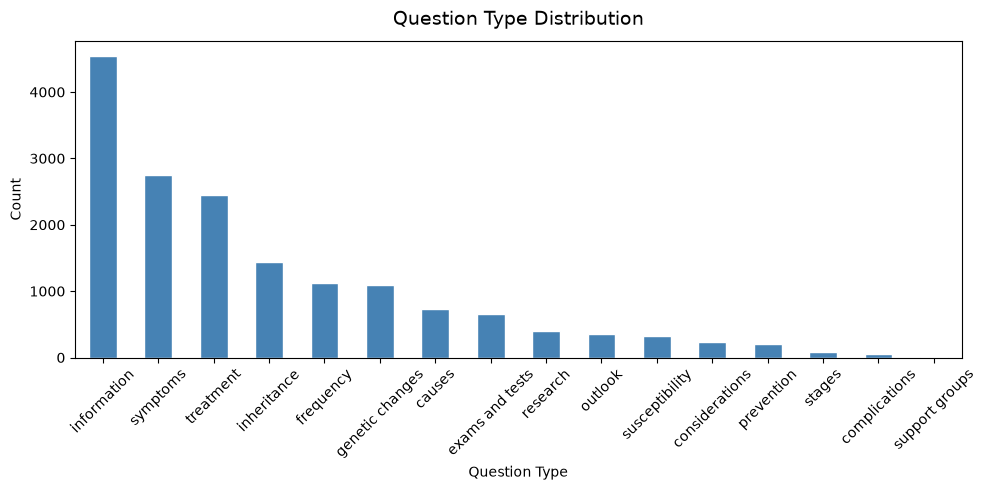

In [6]:
fig, ax = plt.subplots(figsize=(10, 5))
qtype_counts.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Question Type Distribution', fontsize=14, pad=12)
ax.set_xlabel('Question Type')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

## 4. Answer & Question Length Analysis

This is important for setting `max_seq_length` in `config.py`.
If most answers are short, we might be wasting capacity. If many are long, we're truncating useful content.

In [7]:
df['question_len'] = df['Question'].str.split().str.len()
df['answer_len']   = df['Answer'].str.split().str.len()

print('Question length (words):')
print(df['question_len'].describe().round(1))
print()
print('Answer length (words):')
print(df['answer_len'].describe().round(1))

Question length (words):
count    16407.0
mean         8.2
std          2.4
min          3.0
25%          6.0
50%          8.0
75%         10.0
max         27.0
Name: question_len, dtype: float64

Answer length (words):
count    16407.0
mean       201.4
std        248.5
min          1.0
25%         71.0
50%        138.0
75%        252.0
max       4281.0
Name: answer_len, dtype: float64


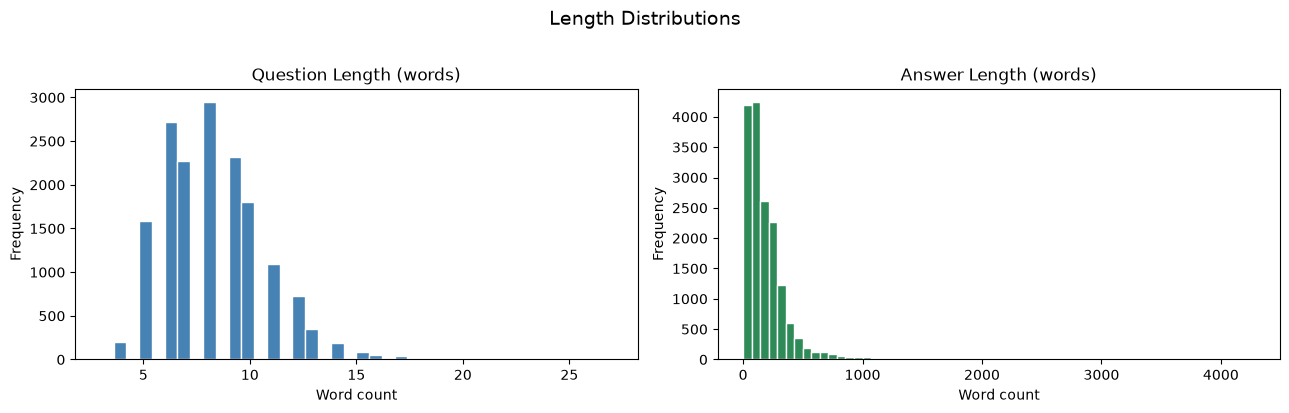

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(df['question_len'], bins=40, color='steelblue', edgecolor='white')
axes[0].set_title('Question Length (words)')
axes[0].set_xlabel('Word count')
axes[0].set_ylabel('Frequency')

axes[1].hist(df['answer_len'], bins=60, color='seagreen', edgecolor='white')
axes[1].set_title('Answer Length (words)')
axes[1].set_xlabel('Word count')
axes[1].set_ylabel('Frequency')

plt.suptitle('Length Distributions', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 5. Token Length vs max_seq_length

Word count is an approximation. Let's use the actual tokenizer to see what percentage of examples will be truncated at our `max_seq_length = 512`.

In [ ]:
from transformers import AutoTokenizer
from src.config import model_config, data_config

tokenizer = AutoTokenizer.from_pretrained(model_config.model_name, trust_remote_code=True,local_files_only=True)
print(f'Tokenizer loaded: {model_config.model_name}')

Tokenizer loaded: Qwen/Qwen2.5-1.5B-Instruct


In [10]:
# build the full chat string for each row and count tokens
# we sample 1000 rows for speed
sample_df = df.sample(1000, random_state=42)

def count_tokens(row):
    messages = [
        {'role': 'system',    'content': data_config.system_prompt},
        {'role': 'user',      'content': row['Question']},
        {'role': 'assistant', 'content': row['Answer']},
    ]
    text = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=False)
    return len(tokenizer.encode(text))

sample_df = sample_df.copy()
sample_df['token_count'] = sample_df.apply(count_tokens, axis=1)

print(f'Token count stats (sample of 1000):')
print(sample_df['token_count'].describe().round(1))

pct_truncated = (sample_df['token_count'] > data_config.max_seq_length).mean() * 100
print(f'\nExamples exceeding max_seq_length ({data_config.max_seq_length}): {pct_truncated:.1f}%')

Token count stats (sample of 1000):
count    1000.0
mean      324.6
std       309.5
min        64.0
25%       154.0
50%       244.0
75%       390.8
max      3980.0
Name: token_count, dtype: float64

Examples exceeding max_seq_length (512): 13.2%


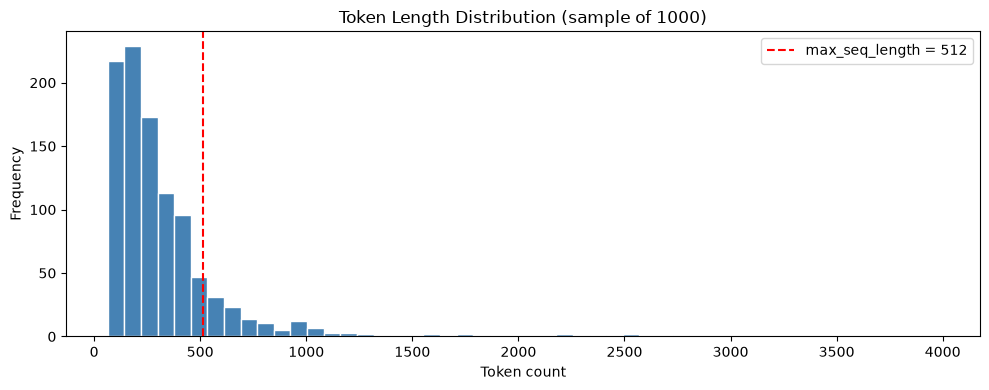

In [11]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(sample_df['token_count'], bins=50, color='steelblue', edgecolor='white')
ax.axvline(data_config.max_seq_length, color='red', linestyle='--', linewidth=1.5,
           label=f'max_seq_length = {data_config.max_seq_length}')
ax.set_title('Token Length Distribution (sample of 1000)')
ax.set_xlabel('Token count')
ax.set_ylabel('Frequency')
ax.legend()
plt.tight_layout()
plt.show()

## 6. Data Quality Check

In [12]:
print('Missing values:')
print(df.isnull().sum())

print(f'\nDuplicate questions : {df["Question"].duplicated().sum()}')
print(f'Duplicate answers   : {df["Answer"].duplicated().sum()}')

very_short_q = df[df['question_len'] < 5]
very_short_a = df[df['answer_len'] < 10]
print(f'\nVery short questions (< 5 words) : {len(very_short_q)}')
print(f'Very short answers   (< 10 words): {len(very_short_a)}')

Missing values:
qtype           0
Question        0
Answer          0
question_len    0
answer_len      0
dtype: int64

Duplicate questions : 1428
Duplicate answers   : 590

Very short questions (< 5 words) : 203
Very short answers   (< 10 words): 79


In [13]:
# look at the very short answers to understand if they're real issues
if len(very_short_a) > 0:
    print('Sample very short answers:')
    print(very_short_a[['Question', 'Answer']].head(5).to_string())

Sample very short answers:
                                                                                  Question                                                                            Answer
20                                    what can i do to prevent poisoning by marine toxins?                                  General guidelines for safe seafood consumption:
40            What is (are) Parasites - Toxocariasis (also known as Roundworm Infection) ?  Frequently Asked Questions (FAQs)\n    \n    \n                \n    Fact Sheets
49      How to prevent Acanthamoeba - Granulomatous Amebic Encephalitis (GAE); Keratitis ?                                                                            Topics
128                                       What is (are) Parasites - Lymphatic Filariasis ?                   Frequently Asked Questions (FAQs)\n    \n    Vector Information
174  What is (are) Parasites - African Trypanosomiasis (also known as Sleeping Sickness) ?                  

## 7. Answer Style Variation by Question Type

Since `reformat.py` (Phase 2) uses heuristics to split answers into sections,
it's worth checking whether answer style varies significantly across question types.

In [14]:
avg_len_by_type = df.groupby('qtype')['answer_len'].mean().sort_values(ascending=False).round(1)
print('Average answer length (words) by question type:')
print(avg_len_by_type)

Average answer length (words) by question type:
qtype
stages             898.8
exams and tests    318.7
prevention         309.8
symptoms           301.1
susceptibility     244.8
treatment          217.1
considerations     212.1
genetic changes    208.0
complications      206.8
causes             202.1
information        183.4
research           152.9
support groups     102.0
inheritance         96.7
outlook             71.2
frequency           30.4
Name: answer_len, dtype: float64


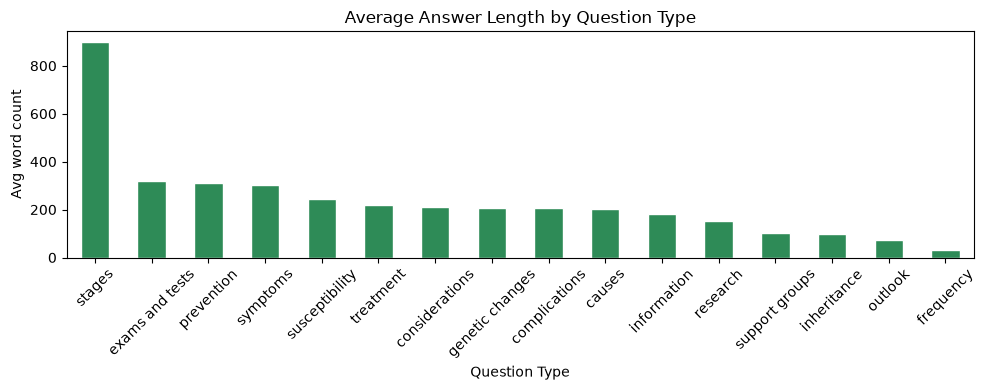

In [15]:
fig, ax = plt.subplots(figsize=(10, 4))
avg_len_by_type.plot(kind='bar', ax=ax, color='seagreen', edgecolor='white')
ax.set_title('Average Answer Length by Question Type')
ax.set_xlabel('Question Type')
ax.set_ylabel('Avg word count')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

## 8. Summary & Observations

- **Dataset size**: 16,407 rows across 3 columns (qtype, Question, Answer). No missing values in any column.

- **Question types**: 16 distinct types. Heavily dominated by `information` (4,535 rows) and `symptoms` (2,748), followed by `treatment` (2,442) and `inheritance` (1,446). The `support groups` type has only 1 row — effectively negligible for training.

- **Question length**: Very short and consistent — median 8 words, max 27. Questions are well-formed and uniform across the dataset, so no special handling needed.

- **Answer length**: Highly variable — median 138 words, mean 201, but max reaches 4,281 words (std 248). This is driven by question type: `stages` averages 899 words while `frequency` averages only 30. The model will see a wide range of answer lengths.

- **Token length**: Median 244 tokens on a 1,000-row sample. **13.2% of examples exceed max_seq_length=512**, meaning those answers get truncated during training. This is acceptable — we lose the tail of long answers, not entire examples.

- **Quality issues**: 1,428 duplicate questions and 590 duplicate answers found. 203 very short questions (< 5 words) and 79 very short answers (< 10 words) — some clearly broken (e.g. answers containing only "Frequently Asked Questions (FAQs)" with no real content). All filtered out in `prepare.py`.

- **Key insight**: The extreme answer length variance across question types (`frequency` at 30 words vs `stages` at 899) means Phase 2 structured formatting will work well on short answers but may be lossy on very long ones — the heuristic section splitting in `reformat.py` is better suited to medium-length answers.

- **Impact on training**: `max_seq_length=512` is the right tradeoff for a 4GB GPU — 13.2% truncation is acceptable given the distribution. The 90/10 shuffle split in `prepare.py` may place near-identical duplicate rows in both train and val, slightly inflating validation metrics — acceptable for a learning project but worth noting.